In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_csv('diabetes.csv')

In [76]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [78]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Bazı kolonların minimumları 0, bazı yerler boşmuş ve null yerine 0 yazıp geçmiş olmalılar.

In [79]:
df['Insulin'].value_counts()

,count
Insulin,
0,374
105,11
130,9
140,9
120,8
...,...
178,1
127,1
510,1


Büyük çoğunluğu 0 ve insülin 0 olmaması gereken bir değer, bunun veri eksikliğinden kaynaklandığını tahmin ediyoruz.

In [80]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [81]:
columns_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in columns_to_check:
    zero_count = (df[col] == 0).sum()
    print(zero_count)

5
35
227
374
11


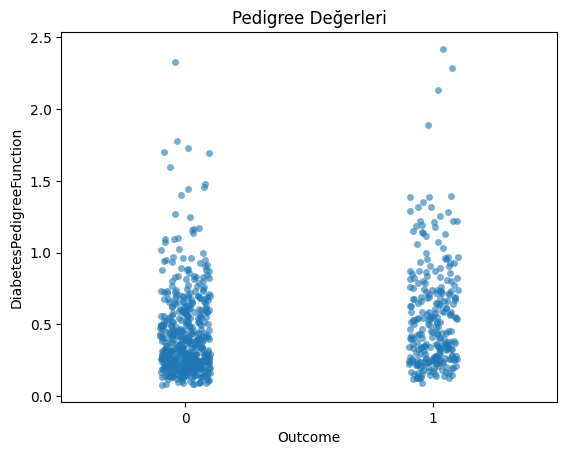

In [82]:
sns.stripplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, jitter=True, alpha=0.6)
plt.title('Pedigree Değerleri')
plt.show()

Kaç satırda 0 olduğunu yazdırdık, null olan değerler yerine 0 kullanılmış. Hangi kolonları droplayıp hangilerini mock data ile dolduracağımıza karar vermeliyiz.

In [83]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [84]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [85]:
columns_to_fill = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

Çok fazla outlier olduğundan mod değil medyanı kullanıcaz boşlukları doldururken.

In [86]:
for col in columns_to_fill:
  print(X_train[X_train[col] != 0])

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
304            3      150             76              0        0  21.0   
297            0      126             84             29      215  30.7   
522            6      114              0              0        0   0.0   
618            9      112             82             24        0  28.2   
501            3       84             72             32        0  37.2   
..           ...      ...            ...            ...      ...   ...   
156            2       99             52             15       94  24.6   
384            1      125             70             24      110  24.3   
645            2      157             74             35      440  39.4   
757            0      123             72              0        0  36.3   
456            1      135             54              0        0  26.7   

     DiabetesPedigreeFunction  Age  
304                     0.207   37  
297                     0.520   24  


In [87]:
medians = {}
for col in columns_to_fill:
  median_value = X_train[X_train[col] != 0][col].median()
  X_train[col] = X_train[col].replace(0, median_value)

for col in columns_to_fill:
  X_test[col] = X_test[col].replace(0, median_value)

In [88]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.907166,121.560261,72.612378,29.040717,142.477199,32.448208,0.469948,33.285016
std,3.385438,29.974412,12.165642,8.312217,80.879330,6.862948,0.328516,11.678337
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.238250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.370500,29.000000
75%,6.000000,139.750000,80.000000,32.000000,130.000000,36.500000,0.630750,40.000000
max,17.000000,199.000000,122.000000,63.000000,680.000000,67.100000,2.420000,81.000000


In [89]:
X_test.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,3.597403,122.038961,69.424675,30.190909,96.433766,32.483117,0.479565,33.064935
std,3.304818,32.320876,14.681887,10.580352,121.213781,6.946159,0.343303,12.118519
min,0.000000,61.000000,30.000000,7.000000,23.000000,18.400000,0.078000,21.000000
25%,1.000000,95.250000,62.000000,23.250000,32.300000,26.925000,0.254000,24.000000
50%,3.000000,117.000000,70.000000,32.300000,32.300000,32.300000,0.376500,28.000000
75%,5.750000,142.750000,80.000000,33.750000,112.750000,36.950000,0.603750,41.000000
max,13.000000,197.000000,106.000000,99.000000,846.000000,55.000000,2.329000,69.000000


In [90]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [91]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [92]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [93]:
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154

0.7532467532467533
[[87 21]
 [17 29]]


Hyperparameter Tuning yapmayı deneyelim.

In [94]:
from sklearn.model_selection import GridSearchCV

In [95]:
adaboost_params = {
    "n_estimators": [50, 70, 100, 120, 150, 200],
    "learning_rate" : [0.001, 0.01, 0.1, 1, 10]}

In [96]:
grid = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=adaboost_params, cv=3, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


GridSearchCV(cv=3, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1, 10],
                         'n_estimators': [50, 70, 100, 120, 150, 200]},
             verbose=1)

In [97]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 200}

In [98]:
ada = AdaBoostClassifier(learning_rate=1, n_estimators=150)

In [99]:
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84       108
           1       0.61      0.65      0.63        46

    accuracy                           0.77       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.78      0.77      0.77       154

0.7727272727272727
[[89 19]
 [16 30]]


Çok da fazla bir değişiklik olmadığını söyleyebiliriz.